## Problema - Organización y búsqueda de productos en una tienda

**Instrucción:** completa esta plantilla con tu diseño y desarrollo. Evita incluir soluciones generadas automáticamente.



In [ ]:
nombre_estudiante = "Mariana Shenoa Castiblanco González, Emmanuel Alejandro Gil León, Thaliana Rocio Sierra García, Juan José Mican Rodríguez"
carnet = None


## 1) Descripción del problema **[1 pts]**
Una empresa de mensajería necesita recorrer una red de centros de distribución conectados mediante rutas terrestres. Cada centro se representa como un vértice y cada ruta como una arista de un grafo no dirigido.

El programa permitirá representar la red con una lista de adyacencia, realizar recorridos BFS y DFS, buscar un centro mediante BFS y agregar nuevos centros y conexiones.

## 2) Requerimientos **[2 pts]**

Lista requerimientos **funcionales** y **no funcionales**.


### Requerimientos funcionales
- RF01. Representar la red mediante una lista de adyacencia.
- RF02. Mostrar las conexiones de cada centro.
- RF03. Ejecutar BFS desde un centro seleccionado utilizando una cola.
- RF04. Mostrar el nivel de cada centro durante BFS.
- RF05. Ejecutar DFS desde un centro seleccionado utilizando una pila.
- RF06. Buscar un centro mediante BFS y mostrar la ruta y cantidad de conexiones.
- RF07. Agregar nuevos centros y conexiones en ambos sentidos.
- RF08. Validar que los centros ingresados existan cuando corresponda.

### Requerimientos no funcionales
- RNF01. Cada vértice debe visitarse una sola vez por recorrido.
- RNF02. No se deben utilizar librerías que implementen directamente BFS o DFS.
- RNF03. El programa debe ser claro y ejecutable en Python.
- RNF04. Las conexiones deben mantenerse como grafo no dirigido.

## 3) Historias de usuario **[2 pts]**

**HU01 – Recorrer la red con BFS**  
Como administrador, quiero seleccionar un centro inicial para recorrer la red con BFS, para conocer los centros según su cantidad de conexiones desde el origen.

**Criterios de aceptación:**
- El centro inicial debe existir.
- BFS debe utilizar una cola.
- Cada centro debe visitarse una sola vez.
- Se debe mostrar el nivel de cada centro.

**HU02 – Inspeccionar la red con DFS**  
Como administrador, quiero seleccionar un centro inicial para recorrer la red con DFS, para inspeccionar las rutas avanzando lo máximo posible antes de regresar.

**Criterios de aceptación:**
- El centro inicial debe existir.
- DFS debe utilizar una pila o una implementación equivalente mediante recursividad.
- Cada centro debe visitarse una sola vez.

**HU03 – Buscar un centro**  
Como administrador, quiero buscar un centro desde un origen usando BFS, para conocer la ruta utilizada y la cantidad de conexiones.

**Criterios de aceptación:**
- Se debe indicar el centro inicial y el centro objetivo.
- Si existe una ruta, debe mostrarse la ruta completa.
- Si no existe, debe informarse que no hay ruta.

**HU04 – Ampliar la red**  
Como administrador, quiero agregar nuevos centros y conectarlos con centros existentes, para ampliar la red de distribución.

**Criterios de aceptación:**
- El nuevo centro debe incorporarse a la lista de adyacencia.
- Las conexiones deben agregarse en ambos sentidos.
- Después de agregarlo se debe poder mostrar y recorrer la nueva red.

## 4) Diagramas de flujo **[5 pts]**
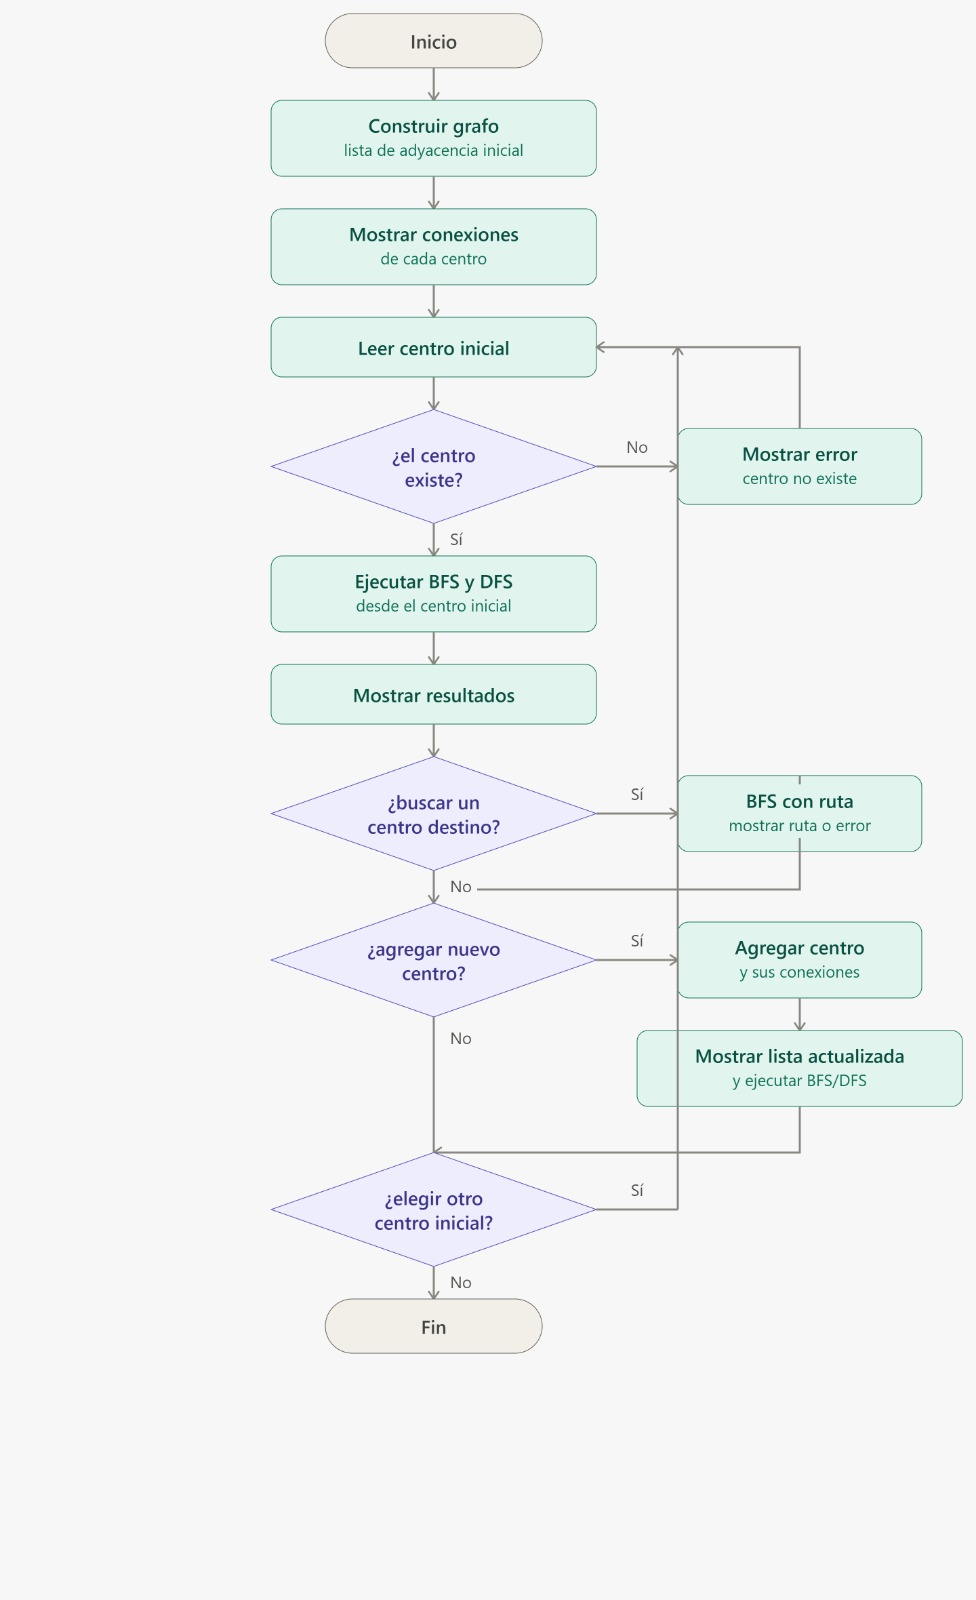
- **Flujo general:** construye el grafo, pide un centro válido, corre BFS y DFS, y opcionalmente busca un destino o agrega un centro nuevo, con la posibilidad de repetir el ciclo.

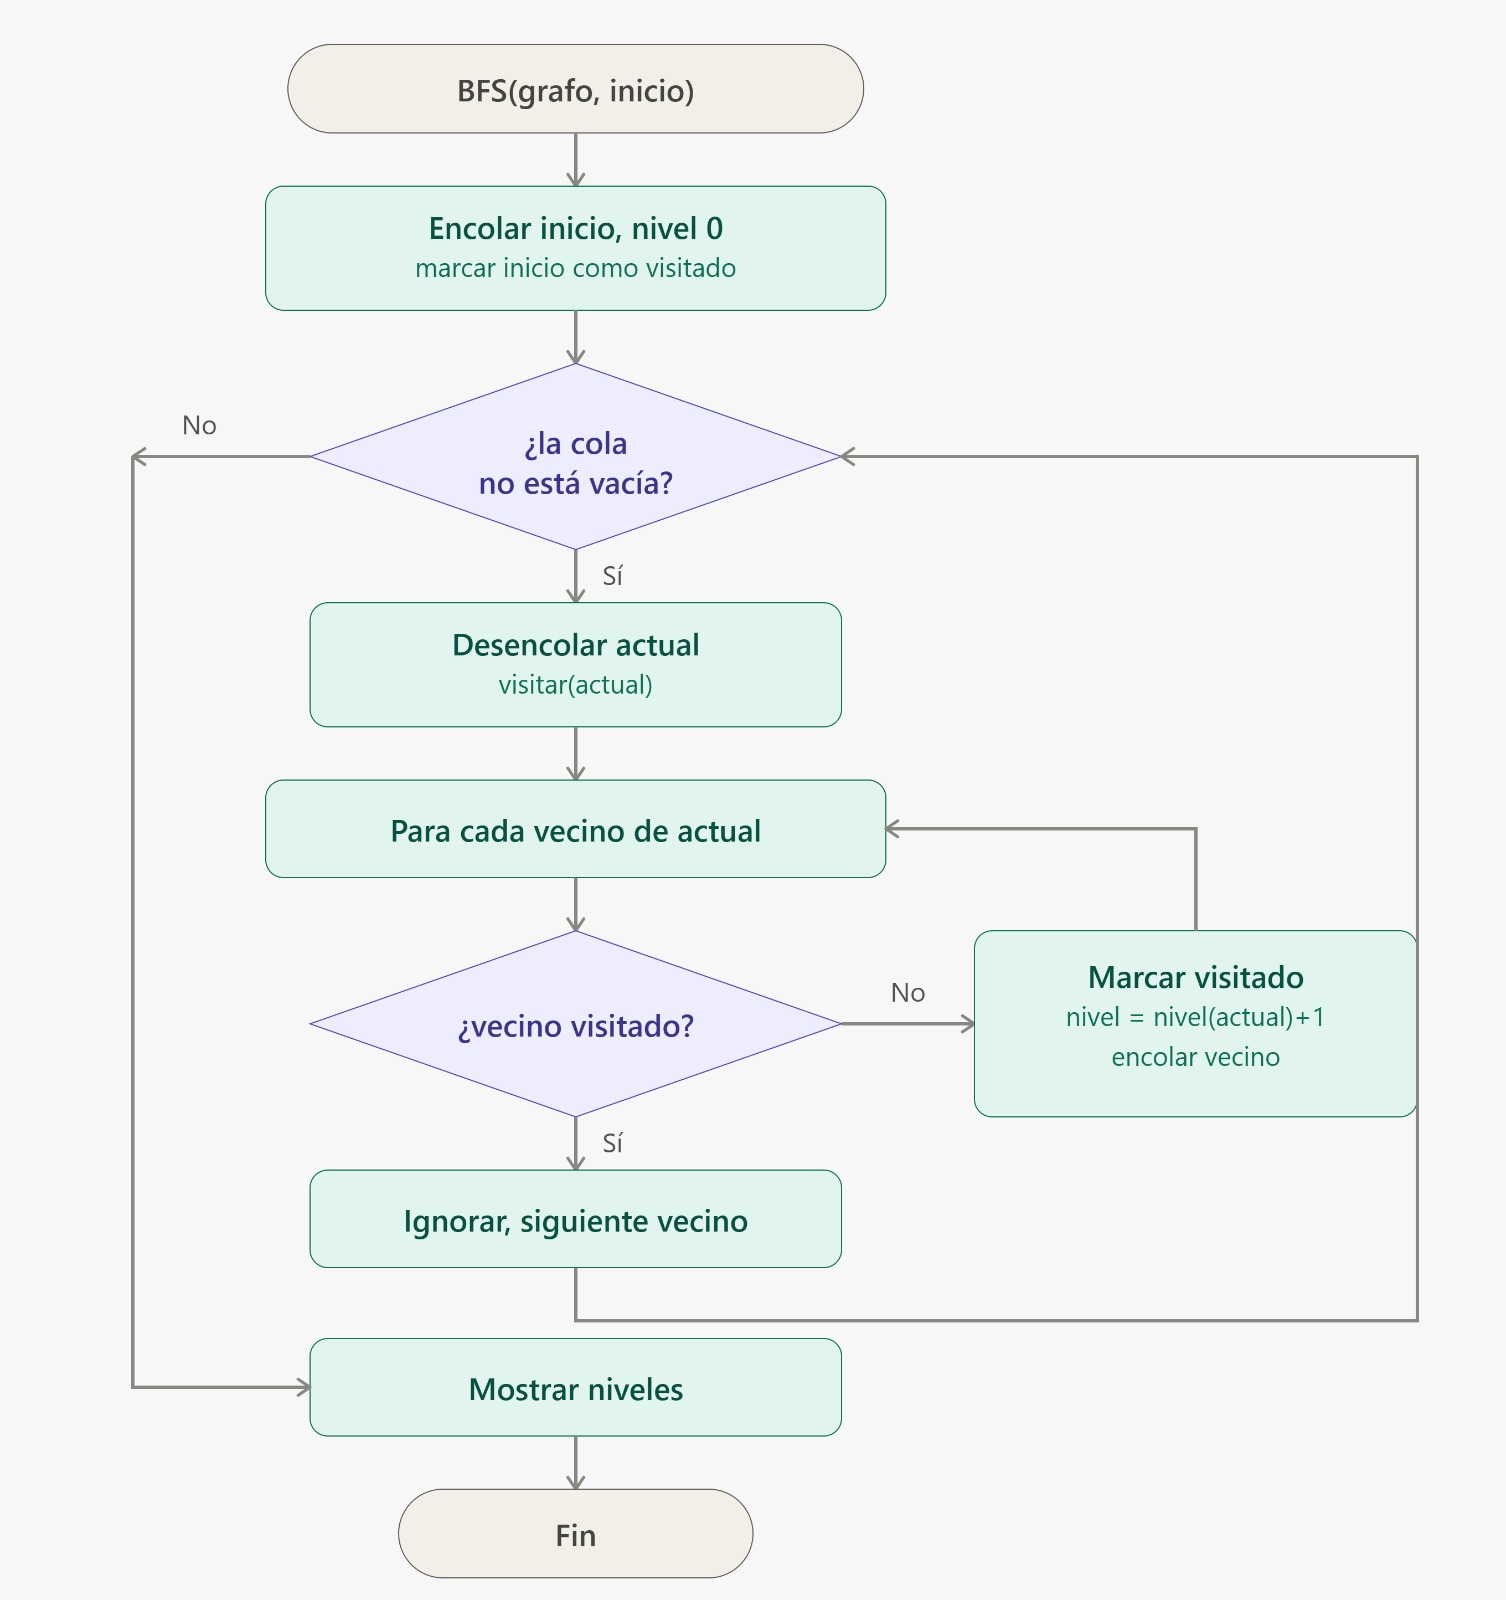
- **BFS:** usa una cola, marca visitados al encolar, y asigna a cada vecino el nivel del nodo actual más uno.

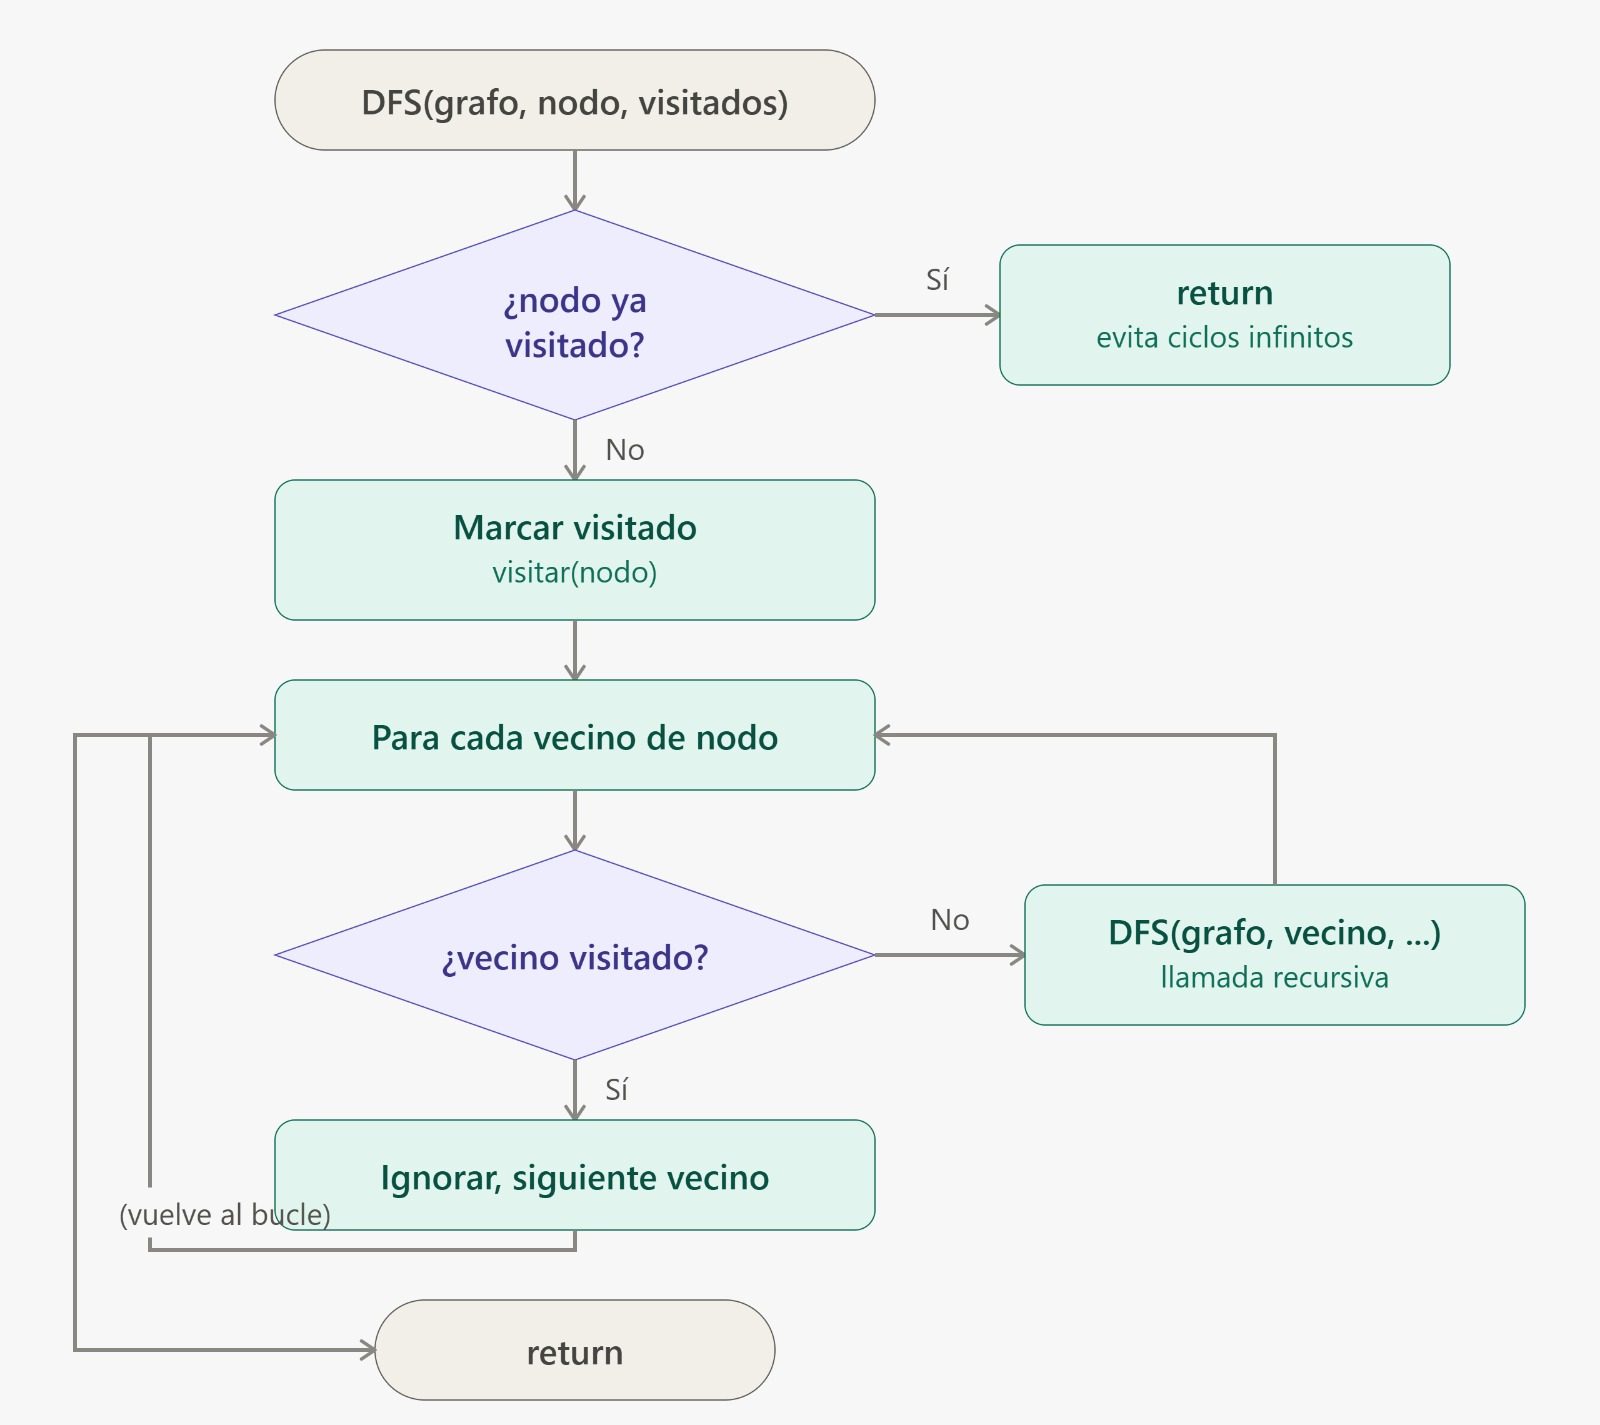
- **DFS recursivo:** marca y visita el nodo, luego llama recursivamente sobre cada vecino no visitado, avanzando al máximo antes de retroceder.

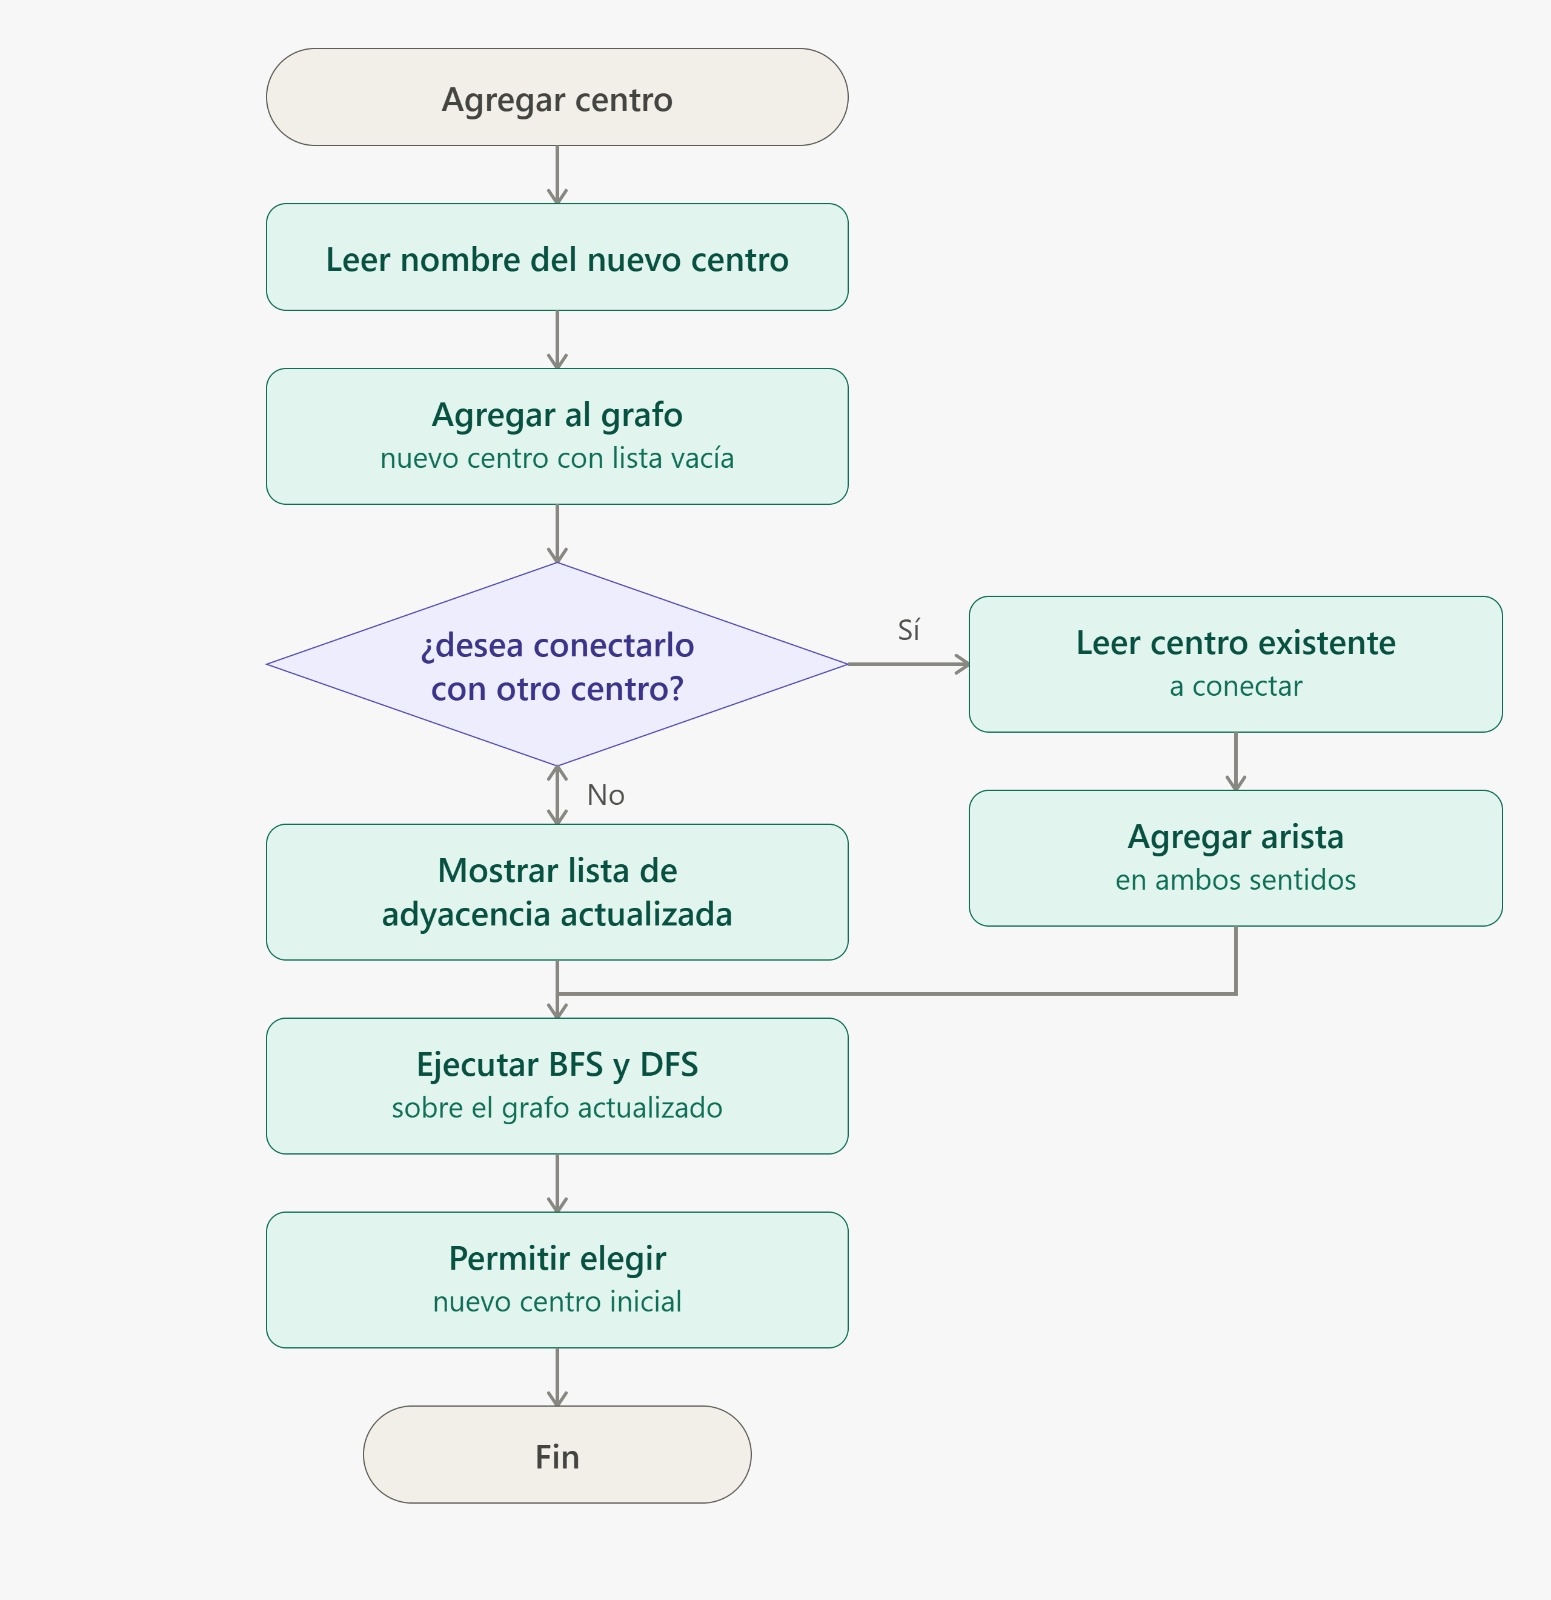
- **Agregar centro:** crea la entrada vacía del nuevo centro y, en un bucle, conecta cada arista en ambos sentidos porque el grafo es no dirigido.
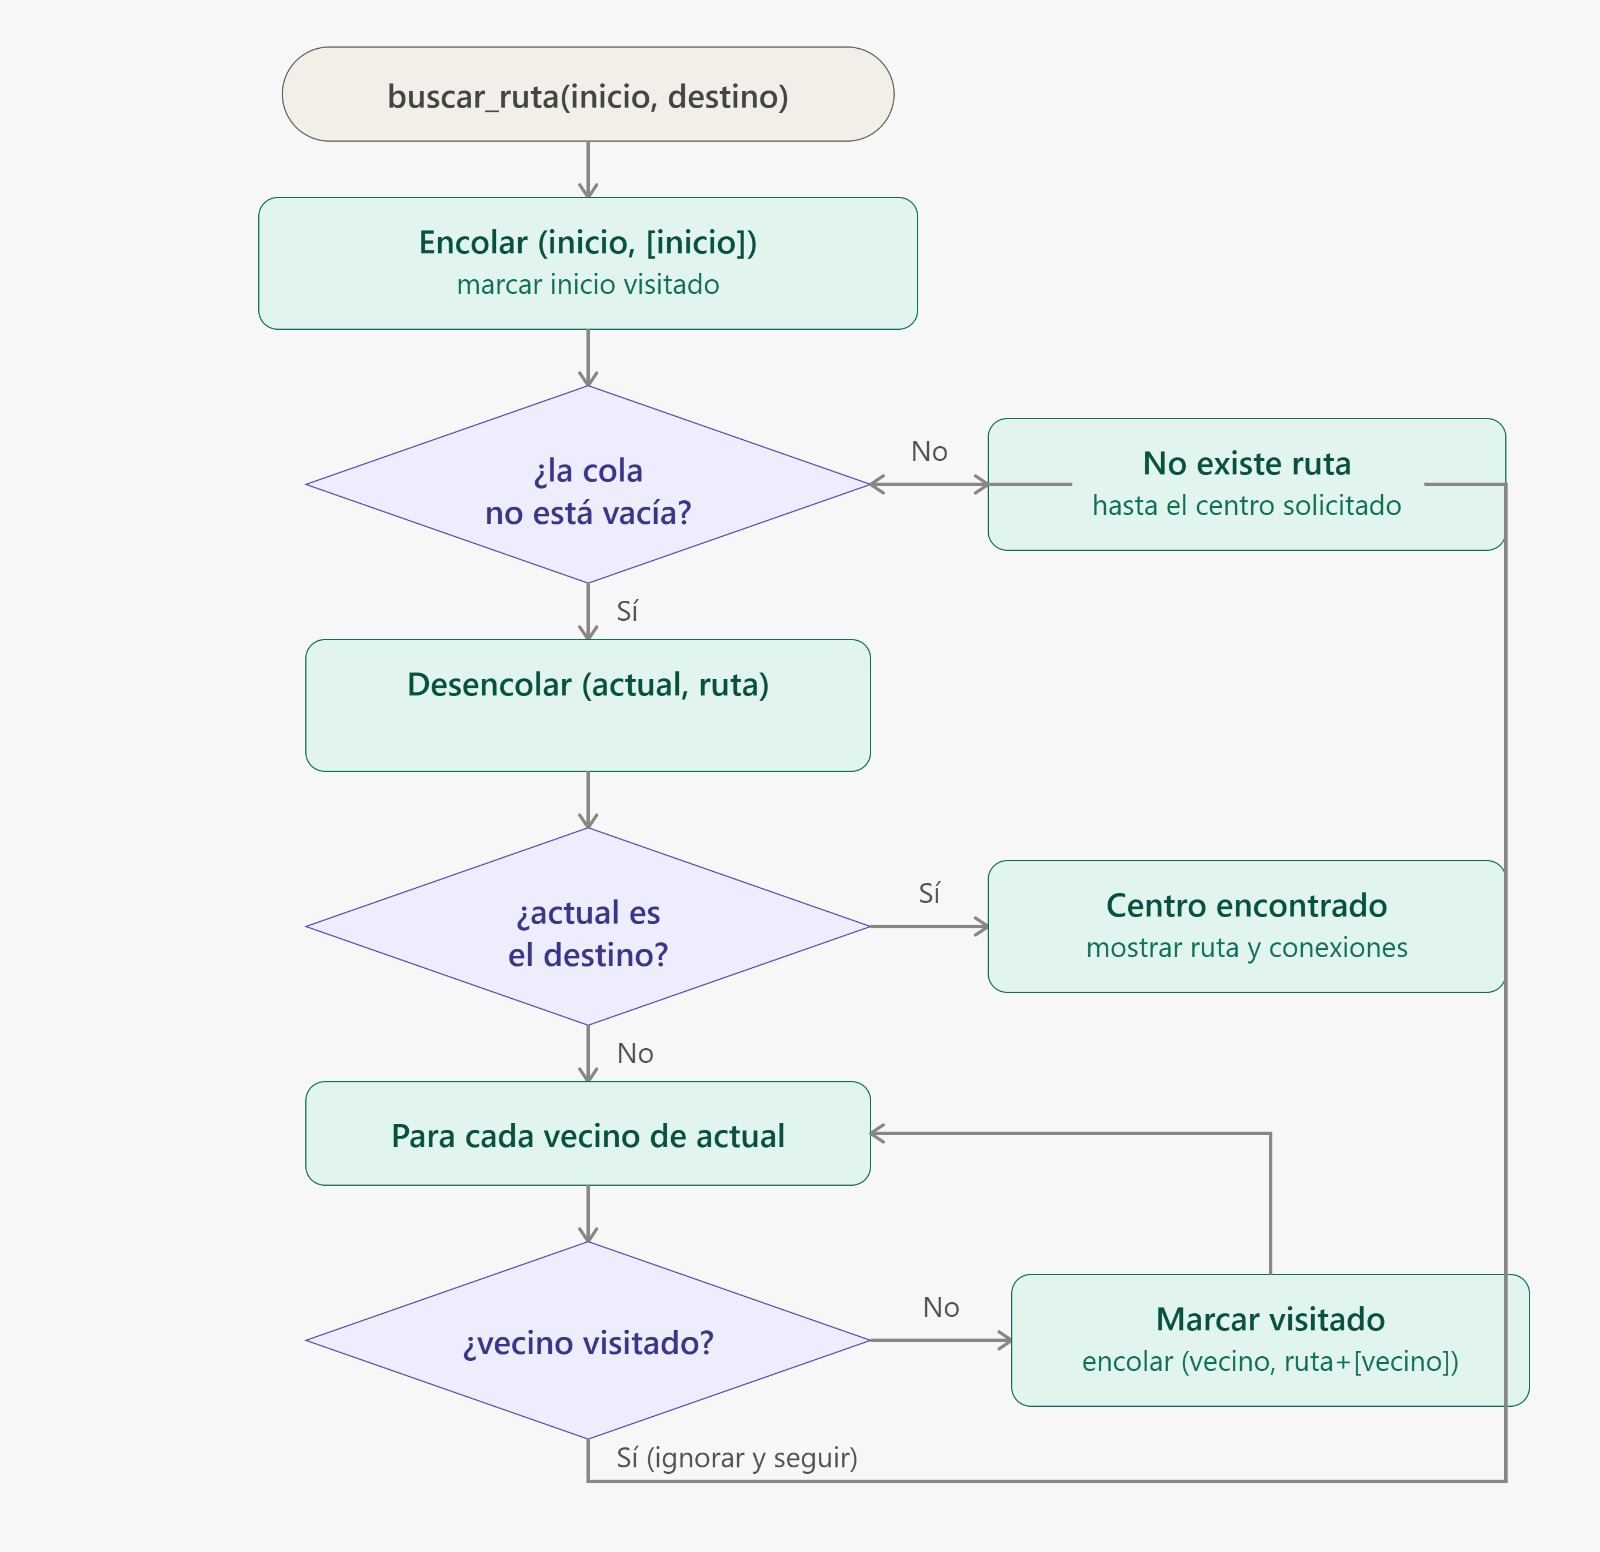

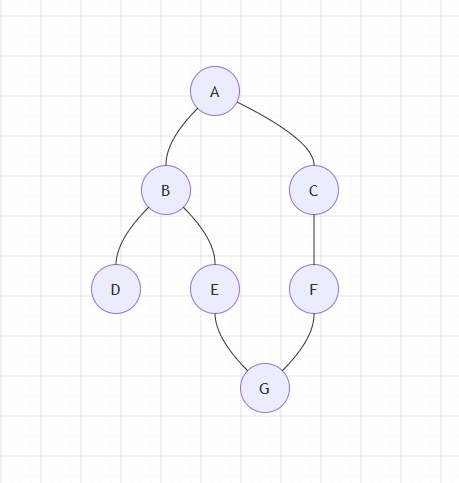

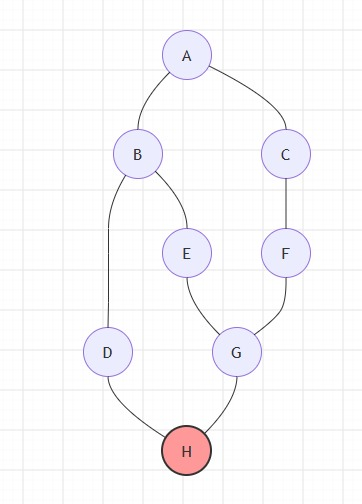

### 5) Análisis de complejidad **[15 pts]**
Sea **V** el número de vértices y **E** el número de aristas.

### BFS
Cada vértice se visita una vez y cada arista se revisa una cantidad constante de veces. Por ello:

**T(V,E) = O(V + E)**

### DFS
Cada vértice se visita una vez y se recorren las aristas de la lista de adyacencia:

**T(V,E) = O(V + E)**

### Búsqueda de un centro con BFS
En el peor caso se puede recorrer todo el grafo antes de encontrar el objetivo o determinar que no existe una ruta:

**T(V,E) = O(V + E)**

### Mejor y peor caso
- Mejor caso: el objetivo coincide con el centro inicial, por lo que la búsqueda termina inmediatamente: **O(1)**.
- Peor caso: el objetivo está al final del recorrido o no es alcanzable: **O(V + E)**.

### Función T[n]
La función de tiempo se expresa como:

$$T(V,E) = c_1V + c_2E + c_3$$

Para un grafo disperso, donde **E = O(V)**, la complejidad se simplifica a:

$$T(n) = O(n)$$

### Complejidad espacial
La memoria adicional de BFS es **O(V)** por la cola, los vértices visitados y los niveles. DFS requiere **O(V)** por la pila y los vértices visitados. La búsqueda mediante BFS también utiliza **O(V)** para la cola, los visitados y el diccionario de padres.

### Gráfica del mejor y peor caso




## 6) Código funcional **[15 pts]**
Incluye tu implementación completa.

No pegues código incompleto; debe ser ejecutable.


In [1]:
from collections import deque

graph = {
    "A": ["B", "C"],
    "B": ["A", "D", "E"],
    "C": ["A", "F"],
    "D": ["B"],
    "E": ["B", "G"],
    "F": ["C", "G"],
    "G": ["E", "F"]
}

def show_graph(graph):
    print("\n===== LISTA DE ADYACENCIA =====")

    for center in graph:
        print(f"{center}: {', '.join(graph[center])}")

def bfs(graph, start):
    if start not in graph:
        return None, None

    queue = deque([start])
    visited = {start}
    levels = {start: 0}
    traversal = []

    while queue:
        current = queue.popleft()
        traversal.append(current)

        for neighbor in graph[current]:
            if neighbor not in visited:
                visited.add(neighbor)
                levels[neighbor] = levels[current] + 1
                queue.append(neighbor)

    return traversal, levels

def dfs(graph, start):
    if start not in graph:
        return None

    stack = [start]
    visited = set()
    traversal = []

    while stack:
        current = stack.pop()

        if current in visited:
            continue

        visited.add(current)
        traversal.append(current)

        for neighbor in reversed(graph[current]):
            if neighbor not in visited:
                stack.append(neighbor)

    return traversal

def search_bfs(graph, start, target):
    if start not in graph or target not in graph:
        return None

    queue = deque([start])
    visited = {start}
    parent = {start: None}

    while queue:
        current = queue.popleft()

        if current == target:
            path = []

            while current is not None:
                path.append(current)
                current = parent[current]
            path.reverse()
            return path

        for neighbor in graph[current]:
            if neighbor not in visited:
                visited.add(neighbor)
                parent[neighbor] = current
                queue.append(neighbor)

    return None

def add_center(graph, new_center, connections):
    if new_center in graph:
        print(f"El centro {new_center} ya existe.")
        return False

    graph[new_center] = []

    for center in connections:
        if center in graph and center != new_center:
            if center not in graph[new_center]:
                graph[new_center].append(center)
            if new_center not in graph[center]:
                graph[center].append(new_center)

        else:
            print(
                f"No se agregó la conexión con {center}: "
                "el centro no existe."
            )

    return True

def show_bfs(graph, start):
    traversal, levels = bfs(graph, start)

    if traversal is None:
        print("Error: el centro ingresado no existe.")
        return

    print(
        f"\nRecorrido BFS desde {start}: "
        f"{' -> '.join(traversal)}"
    )
    print("\nNiveles BFS:")

    for level in sorted(set(levels.values())):
        centers = [
            center
            for center in traversal
            if levels[center] == level
        ]
        print(
            f"Nivel {level}: "
            f"{', '.join(centers)}"
        )

def show_dfs(graph, start):
    traversal = dfs(graph, start)

    if traversal is None:
        print("Error: el centro ingresado no existe.")
        return

    print(
        f"\nRecorrido DFS desde {start}: "
        f"{' -> '.join(traversal)}"
    )

def run_traversals(graph, start):
    if start not in graph:
        print("\nError: el centro ingresado no existe.")
        return

    show_bfs(graph, start)
    show_dfs(graph, start)

def main():

    while True:
        print("\n")
        print("==========================================")
        print("       RED DE DISTRIBUCIÓN")
        print("==========================================")
        print("1. Mostrar lista de adyacencia")
        print("2. Ejecutar BFS y DFS desde un centro")
        print("3. Buscar un centro con BFS")
        print("4. Agregar un nuevo centro")
        print("0. Salir")
        print("==========================================")

        option = input("Seleccione una opción: ").strip()

        if option == "1":
            show_graph(graph)

        elif option == "2":
            start = input("\nIngrese el centro inicial: ").strip().upper()
            run_traversals(graph, start)

        elif option == "3":
            start = input("\nCentro inicial: ").strip().upper()
            target = input("Centro que desea buscar: ").strip().upper()

            if start not in graph:
                print(
                    "\nError: el centro inicial "
                    "no existe."
                )

            elif target not in graph:
                print(
                    "\nError: el centro que desea "
                    "buscar no existe."
                )

            else:
                path = search_bfs(
                    graph,
                    start,
                    target
                )

                if path:
                    print("\nCentro encontrado.")
                    print(f"Ruta: {' -> '.join(path)}")
                    print(
                        f"Cantidad de conexiones: "
                        f"{len(path) - 1}"
                    )

                else:
                    print(
                        "\nNo existe una ruta "
                        "hasta el centro solicitado."
                    )

        elif option == "4":
            new_center = input("\nIngrese el nuevo centro: ").strip().upper()

            if new_center in graph:
                print("Error: ese centro ya existe.")
                continue

            show_graph(graph)

            input_connections = input(
                "\nIngrese los centros con los que "
                "desea conectarlo separados por coma: "
            ).strip().upper()

            connections = [
                center.strip()
                for center in input_connections.split(",")
                if center.strip()
            ]

            add_center(
                graph,
                new_center,
                connections
            )

            print("\nCentro agregado correctamente.")

            print("\n===== NUEVA RED =====")
            show_graph(graph)

            start = input(
                "\nIngrese el centro desde el cual "
                "desea realizar los recorridos: "
            ).strip().upper()
            run_traversals(graph, start)

        elif option == "0":
            print("\nPrograma finalizado.")
            break

        else:
            print(
                "\nOpción no válida. "
                "Por favor, intente nuevamente."
            )

In [8]:
if __name__ == "__main__":
    main()


,
,==========================================
,       RED DE DISTRIBUCIÓN
,==========================================
,1. Mostrar lista de adyacencia
,2. Ejecutar BFS y DFS desde un centro
,3. Buscar un centro con BFS
,4. Agregar un nuevo centro
,5. Salir
,==========================================
,Seleccione una opción: 5
,
,Programa finalizado.


## 7) Tests aplicados **[15 pts]**

In [7]:
traversal, levels = bfs(graph, "A")

assert traversal == ["A", "B", "C", "D", "E", "F", "G"]
assert levels == {
    "A": 0,
    "B": 1,
    "C": 1,
    "D": 2,
    "E": 2,
    "F": 2,
    "G": 3
}

print("Prueba 1 - BFS: APROBADA")


traversal = dfs(graph, "A")

assert set(traversal) == set(graph.keys())
assert len(traversal) == len(set(traversal))

print("Prueba 2 - DFS: APROBADA")


path = search_bfs(graph, "A", "F")

assert path == ["A", "C", "F"]

print("Prueba 3 - Búsqueda BFS: APROBADA")


traversal, levels = bfs(graph, "Z")

assert traversal is None
assert levels is None

print("Prueba 4 - Centro inexistente: APROBADA")


test_graph = {
    "A": ["B", "C"],
    "B": ["A", "D", "E"],
    "C": ["A", "F"],
    "D": ["B"],
    "E": ["B", "G"],
    "F": ["C", "G"],
    "G": ["E", "F"]
}

add_center(test_graph, "H", ["D", "G"])

assert "H" in test_graph
assert "H" in test_graph["D"]
assert "H" in test_graph["G"]
assert "D" in test_graph["H"]
assert "G" in test_graph["H"]

print("Prueba 5 - Agregar centro: APROBADA")


print("\n===== TODAS LAS PRUEBAS FUERON APROBADAS =====")

Prueba 1 - BFS: APROBADA
,Prueba 2 - DFS: APROBADA
,Prueba 3 - Búsqueda BFS: APROBADA
,Prueba 4 - Centro inexistente: APROBADA
,Prueba 5 - Agregar centro: APROBADA
,
,===== TODAS LAS PRUEBAS FUERON APROBADAS =====
